# 화자 인식 — 분석 (LightGBM / SVM / CatBoost)

**주제: 얼마나 들어야 누구인지 알 수 있는가**

**실험 설계**
```
윈도우별로 동일한 조건으로 학습/테스트

0.3초 피처로 학습 → 0.3초 피처로 테스트
0.5초 피처로 학습 → 0.5초 피처로 테스트
0.75초 피처로 학습 → 0.75초 피처로 테스트
1.0초 피처로 학습 → 1.0초 피처로 테스트
1.5초 피처로 학습 → 1.5초 피처로 테스트
전체 피처로 학습  → 전체 피처로 테스트
```

각 윈도우에서 공정한 조건으로 비교.
VAD 전처리가 추가되어 기존 대비 짧은 윈도우 정확도 향상 기대.

In [1]:
# ── 임포트 & 설정 ──────────────────────────────────────────────
import os, json, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from catboost import CatBoostClassifier

matplotlib.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
warnings.filterwarnings("ignore")

# ── 경로 ──────────────────────────────────────────────────────
BASE       = "/Users/jinbaaaaang/Downloads/New_Sample"
OUTPUT_DIR = os.path.join(BASE, "outputs", "sequences")
TRAIN_DIR  = os.path.join(OUTPUT_DIR, "train")
VAL_DIR    = os.path.join(OUTPUT_DIR, "val")

# ── 설정값 ────────────────────────────────────────────────────
SR         = 16000
HOP_LENGTH = 160
SEED       = 42
DPI        = 100

WINDOW_SECS   = [0.3, 0.5, 0.75, 1.0, 1.5, None]
WINDOW_LABELS = [f"{w}초" if w else "전체" for w in WINDOW_SECS]

random.seed(SEED)
np.random.seed(SEED)

with open(os.path.join(OUTPUT_DIR, "speaker_to_label.json"), encoding="utf-8") as f:
    speaker_to_label = json.load(f)
NUM_SPEAKERS = len(speaker_to_label)

print(f"화자 수   : {NUM_SPEAKERS}명")
print(f"윈도우    : {WINDOW_LABELS}")
print(f"랜덤 기준 : {1/NUM_SPEAKERS*100:.1f}%")

화자 수   : 50명
윈도우    : ['0.3초', '0.5초', '0.75초', '1.0초', '1.5초', '전체']
랜덤 기준 : 2.0%


## 피처 추출 함수

In [2]:
def seq_to_feature(seq, window_sec):
    """
    (41, T) 시퀀스에서 window_sec초치만 잘라서
    평균 + 분산으로 압축한 82차원 벡터 반환.
    window_sec=None이면 전체 사용.
    발화가 윈도우보다 짧으면 None 반환.
    """
    if window_sec is not None:
        n_frames = int(window_sec * SR / HOP_LENGTH)
        if seq.shape[1] < n_frames:
            return None
        seq = seq[:, :n_frames]

    mean = seq.mean(axis=1)  # (41,)
    std  = seq.std(axis=1)   # (41,)
    return np.concatenate([mean, std])  # (82,)


def load_split(data_dir, labels_path, window_sec):
    """
    지정된 윈도우로 피처 행렬 X, 레이블 y 반환.
    파일 순서와 레이블 순서가 일치하도록 정렬.
    """
    labels_all = np.load(labels_path)
    files      = sorted(
        [os.path.join(data_dir, f)
         for f in os.listdir(data_dir) if f.endswith(".npy")]
    )
    assert len(files) == len(labels_all), \
        f"파일 수({len(files)})와 레이블 수({len(labels_all)}) 불일치"

    X, y = [], []
    for fpath, label in zip(files, labels_all):
        seq  = np.load(fpath)
        feat = seq_to_feature(seq, window_sec)
        if feat is None:
            continue
        X.append(feat)
        y.append(label)

    return np.array(X), np.array(y)


# 동작 확인
X_tmp, y_tmp = load_split(
    VAL_DIR,
    os.path.join(OUTPUT_DIR, "labels_val.npy"),
    window_sec=1.0
)
print(f"1.0초 윈도우 → X: {X_tmp.shape}, y: {y_tmp.shape}")

1.0초 윈도우 → X: (965, 82), y: (965,)


## 모델 정의

In [3]:
def get_models():
    """매 윈도우마다 새 모델 인스턴스 반환."""
    return {
        "LightGBM": LGBMClassifier(
            n_estimators=200, learning_rate=0.05,
            max_depth=4, num_leaves=7,
            min_child_samples=20,
            reg_alpha=1.0, reg_lambda=5.0,
            random_state=SEED, verbose=-1
        ),
        "SVM": SVC(
            kernel="rbf", C=1.0, gamma="scale",
            probability=True, random_state=SEED
        ),
        "CatBoost": CatBoostClassifier(
            iterations=200, learning_rate=0.05,
            depth=4, random_seed=SEED, verbose=0
        ),
    }

## 핵심 실험 — 윈도우별 학습/테스트

In [4]:
print("윈도우별 학습/테스트 시작...")
print("=" * 55)

# {모델명: [윈도우별 정확도]}
window_accs  = {"LightGBM": [], "SVM": [], "CatBoost": []}
window_valid = []

# 윈도우별 예측 결과 저장 (혼동 행렬용)
window_preds  = {"LightGBM": [], "SVM": [], "CatBoost": []}
window_labels = []

for w in WINDOW_SECS:
    w_label = f"{w}초" if w else "전체"
    print(f"\n▶ window = {w_label}")

    # 해당 윈도우로 Train/Val 피처 추출
    X_train, y_train = load_split(
        TRAIN_DIR,
        os.path.join(OUTPUT_DIR, "labels_train.npy"),
        window_sec=w
    )
    X_val, y_val = load_split(
        VAL_DIR,
        os.path.join(OUTPUT_DIR, "labels_val.npy"),
        window_sec=w
    )
    print(f"  유효 샘플 — Train: {len(y_train)}, Val: {len(y_val)}")
    window_valid.append(len(y_val))
    window_labels.append(y_val)

    # 정규화 — 해당 윈도우의 Train 기준
    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_val_sc   = scaler.transform(X_val)

    # 윈도우별 새 모델로 학습/평가
    models = get_models()
    for name, model in models.items():
        model.fit(X_train_sc, y_train)
        preds = model.predict(X_val_sc)
        acc   = accuracy_score(y_val, preds)
        window_accs[name].append(acc)
        window_preds[name].append(preds)
        print(f"  [{name}] Val: {acc*100:.1f}%")

print("\n" + "=" * 55)
print(f"랜덤 기준선: {1/NUM_SPEAKERS*100:.1f}%")

윈도우별 학습/테스트 시작...

▶ window = 0.3초
  유효 샘플 — Train: 3854, Val: 979
  [LightGBM] Val: 35.1%
  [SVM] Val: 42.3%
  [CatBoost] Val: 33.5%

▶ window = 0.5초
  유효 샘플 — Train: 3846, Val: 976
  [LightGBM] Val: 40.5%
  [SVM] Val: 47.4%
  [CatBoost] Val: 38.7%

▶ window = 0.75초
  유효 샘플 — Train: 3837, Val: 972
  [LightGBM] Val: 45.9%
  [SVM] Val: 52.2%
  [CatBoost] Val: 43.9%

▶ window = 1.0초
  유효 샘플 — Train: 3799, Val: 965
  [LightGBM] Val: 50.8%
  [SVM] Val: 57.2%
  [CatBoost] Val: 47.3%

▶ window = 1.5초
  유효 샘플 — Train: 3217, Val: 823
  [LightGBM] Val: 56.6%
  [SVM] Val: 63.4%
  [CatBoost] Val: 51.8%

▶ window = 전체
  유효 샘플 — Train: 3854, Val: 980
  [LightGBM] Val: 63.6%
  [SVM] Val: 69.4%
  [CatBoost] Val: 60.1%

랜덤 기준선: 2.0%


## 시각화 — 윈도우별 정확도 곡선 (메인 결과)

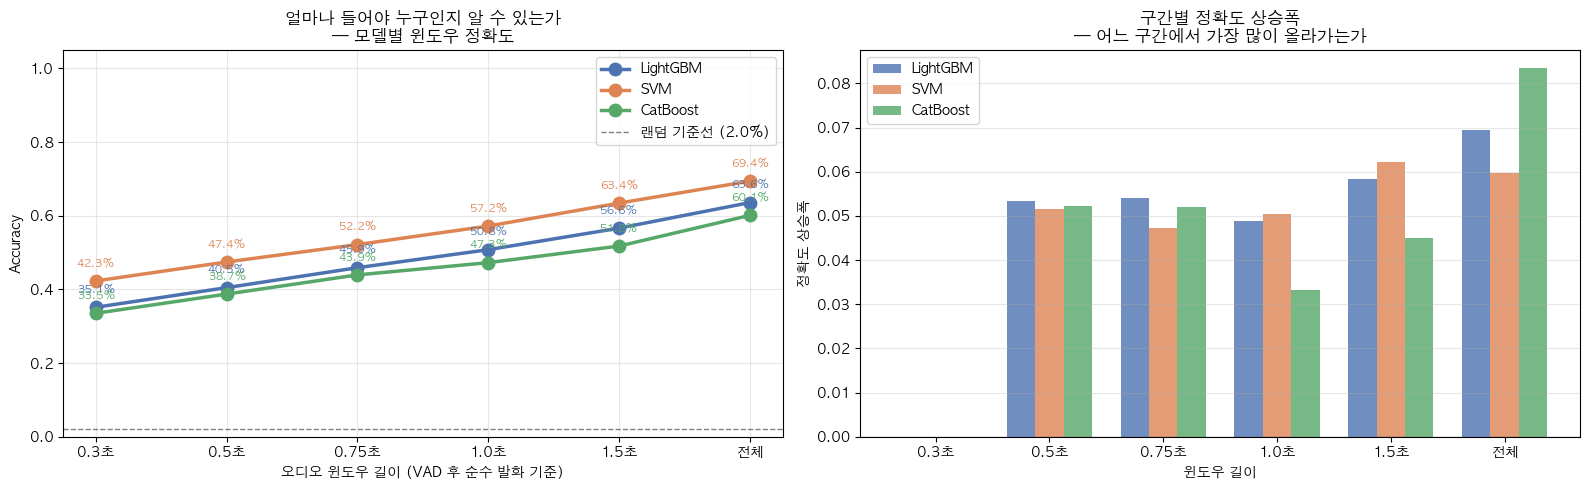

In [5]:
x      = np.arange(len(WINDOW_SECS))
colors = {"LightGBM": "#4C72B0", "SVM": "#DD8452", "CatBoost": "#55A868"}

fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=DPI)

# 왼쪽: 모델별 정확도 곡선
for name, accs in window_accs.items():
    axes[0].plot(x, accs, marker="o", linewidth=2.5, markersize=9,
                 color=colors[name], label=name)
    for xi, acc in zip(x, accs):
        axes[0].annotate(f"{acc*100:.1f}%", (xi, acc),
                          textcoords="offset points", xytext=(0, 10),
                          ha="center", fontsize=8, color=colors[name])

axes[0].axhline(1/NUM_SPEAKERS, color="gray", linestyle="--",
                linewidth=1, label=f"랜덤 기준선 ({1/NUM_SPEAKERS*100:.1f}%)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(WINDOW_LABELS)
axes[0].set_title("얼마나 들어야 누구인지 알 수 있는가\n— 모델별 윈도우 정확도", fontsize=12)
axes[0].set_xlabel("오디오 윈도우 길이 (VAD 후 순수 발화 기준)")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].grid(alpha=0.3)

# 오른쪽: 구간별 정확도 상승폭
w_bar = 0.25
for i, (name, accs) in enumerate(window_accs.items()):
    gains = [0] + [accs[j] - accs[j-1] for j in range(1, len(accs))]
    axes[1].bar(x + i * w_bar, gains, width=w_bar,
                color=colors[name], alpha=0.8, label=name)

axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xticks(x + w_bar)
axes[1].set_xticklabels(WINDOW_LABELS)
axes[1].set_title("구간별 정확도 상승폭\n— 어느 구간에서 가장 많이 올라가는가", fontsize=12)
axes[1].set_xlabel("윈도우 길이")
axes[1].set_ylabel("정확도 상승폭")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 피처별 시간 기여도 분석

In [6]:
# MFCC only / MFCC+Delta / MFCC+Delta+ΔΔ / 전체
# 피처 범위를 바꿔서 같은 윈도우 조건으로 SVM 학습/테스트

FEATURE_SETS = {
    "MFCC only":      (slice(0, 13), slice(41, 54)),
    "MFCC+Delta":     (slice(0, 26), slice(41, 67)),
    "MFCC+Delta+ΔΔ": (slice(0, 39), slice(41, 80)),
    "전체 피처":       (slice(0, 41), slice(41, 82)),
}


def extract_feat_subset(X, mean_sl, std_sl):
    return np.concatenate([X[:, mean_sl], X[:, std_sl]], axis=1)


print("피처별 시간 기여도 분석 중 (SVM 기준)...")
feat_results = {fname: [] for fname in FEATURE_SETS}

for w in WINDOW_SECS:
    w_label = f"{w}초" if w else "전체"

    X_train_w, y_train_w = load_split(
        TRAIN_DIR,
        os.path.join(OUTPUT_DIR, "labels_train.npy"),
        window_sec=w
    )
    X_val_w, y_val_w = load_split(
        VAL_DIR,
        os.path.join(OUTPUT_DIR, "labels_val.npy"),
        window_sec=w
    )
    scaler_w     = StandardScaler()
    X_train_w_sc = scaler_w.fit_transform(X_train_w)
    X_val_w_sc   = scaler_w.transform(X_val_w)

    for fname, (m_sl, s_sl) in FEATURE_SETS.items():
        X_tr_sub = extract_feat_subset(X_train_w_sc, m_sl, s_sl)
        X_vl_sub = extract_feat_subset(X_val_w_sc,   m_sl, s_sl)
        svm = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=SEED)
        svm.fit(X_tr_sub, y_train_w)
        acc = accuracy_score(y_val_w, svm.predict(X_vl_sub))
        feat_results[fname].append(acc)

    print(f"  {w_label} 완료")

print("\n결과 요약")
print("-" * 50)
header = "피처 조합       " + "  ".join(f"{l:>5}" for l in WINDOW_LABELS)
print(header)
for fname, accs in feat_results.items():
    row = f"{fname:<16}" + "  ".join(f"{a*100:>5.1f}%" for a in accs)
    print(row)

피처별 시간 기여도 분석 중 (SVM 기준)...
  0.3초 완료
  0.5초 완료
  0.75초 완료
  1.0초 완료
  1.5초 완료
  전체 완료

결과 요약
--------------------------------------------------
피처 조합        0.3초   0.5초  0.75초   1.0초   1.5초     전체
MFCC only        32.2%   34.4%   36.8%   38.0%   42.9%   39.9%
MFCC+Delta       37.0%   37.8%   41.7%   45.8%   51.4%   56.0%
MFCC+Delta+ΔΔ    38.4%   40.9%   45.2%   48.5%   54.6%   61.6%
전체 피처            42.3%   47.4%   52.2%   57.2%   63.4%   69.4%


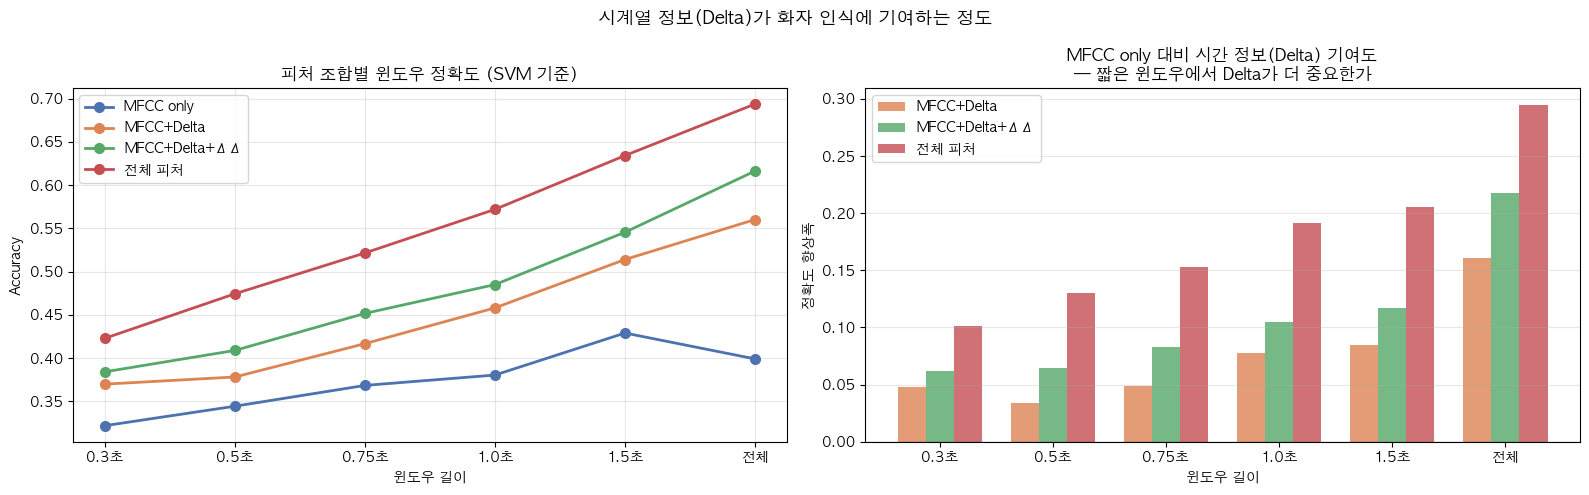

In [7]:
# 피처별 기여도 시각화
colors_feat = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=DPI)

# 왼쪽: 피처 조합별 정확도 곡선
for (fname, accs), color in zip(feat_results.items(), colors_feat):
    axes[0].plot(x, accs, marker="o", linewidth=2, markersize=7,
                 color=color, label=fname)
axes[0].set_xticks(x)
axes[0].set_xticklabels(WINDOW_LABELS)
axes[0].set_title("피처 조합별 윈도우 정확도 (SVM 기준)")
axes[0].set_xlabel("윈도우 길이")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# 오른쪽: MFCC only 대비 Delta 기여도
base = feat_results["MFCC only"]
w_bar = 0.25
for i, (fname, color) in enumerate(
    zip(["MFCC+Delta", "MFCC+Delta+ΔΔ", "전체 피처"], colors_feat[1:])
):
    gains = [a - b for a, b in zip(feat_results[fname], base)]
    axes[1].bar(x + i * w_bar, gains, width=w_bar,
                color=color, alpha=0.8, label=fname)

axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xticks(x + w_bar)
axes[1].set_xticklabels(WINDOW_LABELS)
axes[1].set_title("MFCC only 대비 시간 정보(Delta) 기여도\n— 짧은 윈도우에서 Delta가 더 중요한가")
axes[1].set_xlabel("윈도우 길이")
axes[1].set_ylabel("정확도 향상폭")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("시계열 정보(Delta)가 화자 인식에 기여하는 정도", fontsize=13)
plt.tight_layout()
plt.show()

## Cosine Similarity 분석

In [8]:
def cosine_sim(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8))


def compute_sim_stats(X, y, n_samples=5):
    same_sims, diff_sims = [], []
    speakers = np.unique(y)

    spk_feats = {}
    for spk in speakers:
        idxs = np.where(y == spk)[0][:n_samples]
        spk_feats[spk] = X[idxs]

    for spk in speakers:
        embs = spk_feats[spk]
        for i in range(len(embs)):
            for j in range(i + 1, len(embs)):
                same_sims.append(cosine_sim(embs[i], embs[j]))

    spk_list = list(speakers[:20])
    for i, spk_a in enumerate(spk_list):
        for spk_b in spk_list[i+1:]:
            if len(spk_feats[spk_a]) and len(spk_feats[spk_b]):
                diff_sims.append(
                    cosine_sim(spk_feats[spk_a][0], spk_feats[spk_b][0])
                )

    return (np.mean(same_sims) if same_sims else 0.0,
            np.mean(diff_sims) if diff_sims else 0.0)


print("윈도우별 Cosine Similarity 계산 중...")
same_sim_list, diff_sim_list = [], []

for w in WINDOW_SECS:
    X_val_w, y_val_w = load_split(
        VAL_DIR,
        os.path.join(OUTPUT_DIR, "labels_val.npy"),
        window_sec=w
    )
    scaler_w   = StandardScaler()
    # 해당 윈도우 train 기준으로 정규화
    X_train_w, _ = load_split(
        TRAIN_DIR,
        os.path.join(OUTPUT_DIR, "labels_train.npy"),
        window_sec=w
    )
    scaler_w.fit(X_train_w)
    X_val_w_sc = scaler_w.transform(X_val_w)

    s, d = compute_sim_stats(X_val_w_sc, y_val_w)
    same_sim_list.append(s)
    diff_sim_list.append(d)
    label = f"{w}초" if w else "전체"
    print(f"  window={label:>6} | 같은 화자: {s:.3f} | 다른 화자: {d:.3f} | gap: {s-d:.3f}")

윈도우별 Cosine Similarity 계산 중...
  window=  0.3초 | 같은 화자: 0.080 | 다른 화자: -0.005 | gap: 0.085
  window=  0.5초 | 같은 화자: 0.115 | 다른 화자: 0.000 | gap: 0.115
  window= 0.75초 | 같은 화자: 0.150 | 다른 화자: -0.002 | gap: 0.152
  window=  1.0초 | 같은 화자: 0.168 | 다른 화자: -0.005 | gap: 0.173
  window=  1.5초 | 같은 화자: 0.206 | 다른 화자: -0.018 | gap: 0.224
  window=    전체 | 같은 화자: 0.223 | 다른 화자: -0.013 | gap: 0.236


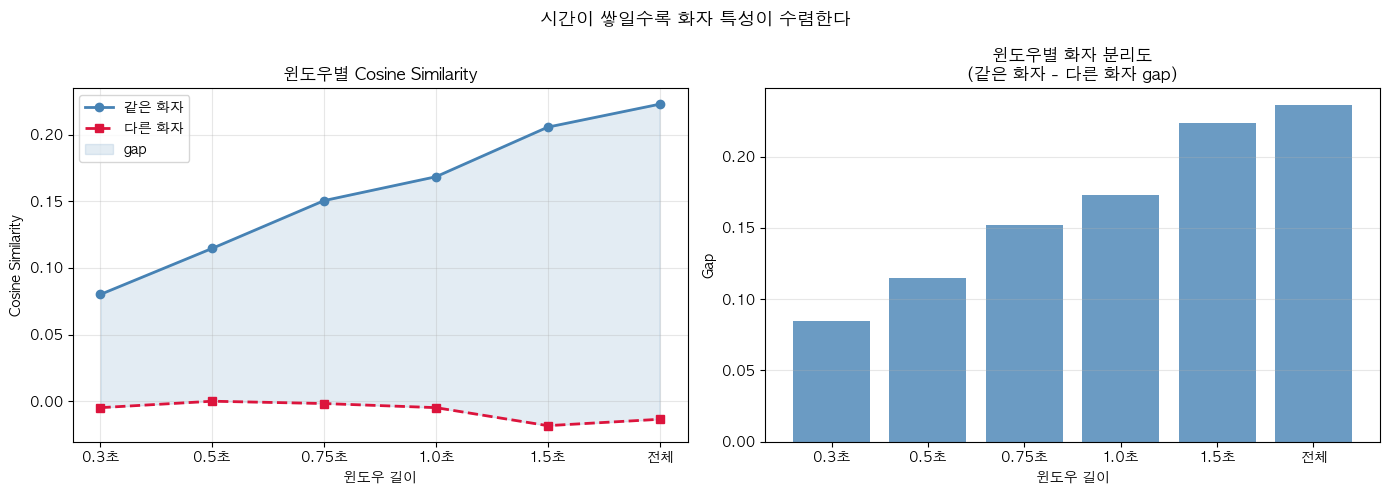

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=DPI)

axes[0].plot(x, same_sim_list, marker="o", linewidth=2,
             color="steelblue", label="같은 화자")
axes[0].plot(x, diff_sim_list, marker="s", linewidth=2,
             color="crimson", linestyle="--", label="다른 화자")
axes[0].fill_between(x, same_sim_list, diff_sim_list,
                     alpha=0.15, color="steelblue", label="gap")
axes[0].set_xticks(x)
axes[0].set_xticklabels(WINDOW_LABELS)
axes[0].set_title("윈도우별 Cosine Similarity")
axes[0].set_xlabel("윈도우 길이")
axes[0].set_ylabel("Cosine Similarity")
axes[0].legend()
axes[0].grid(alpha=0.3)

gaps = [s - d for s, d in zip(same_sim_list, diff_sim_list)]
axes[1].bar(x, gaps, color="steelblue", alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(WINDOW_LABELS)
axes[1].set_title("윈도우별 화자 분리도\n(같은 화자 - 다른 화자 gap)")
axes[1].set_xlabel("윈도우 길이")
axes[1].set_ylabel("Gap")
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("시간이 쌓일수록 화자 특성이 수렴한다", fontsize=13)
plt.tight_layout()
plt.show()

## 정보량 포화 분석

In [10]:
print("정보량 포화 분석 중...")
intra_vars, inter_vars, separabilities = [], [], []

for w in WINDOW_SECS:
    X_val_w, y_val_w = load_split(
        VAL_DIR,
        os.path.join(OUTPUT_DIR, "labels_val.npy"),
        window_sec=w
    )
    X_train_w, _ = load_split(
        TRAIN_DIR,
        os.path.join(OUTPUT_DIR, "labels_train.npy"),
        window_sec=w
    )
    scaler_w   = StandardScaler().fit(X_train_w)
    X_val_w_sc = scaler_w.transform(X_val_w)

    intra_list, spk_means = [], []
    for spk in np.unique(y_val_w):
        idxs     = np.where(y_val_w == spk)[0]
        spk_data = X_val_w_sc[idxs]
        if len(spk_data) < 2:
            continue
        intra_list.append(spk_data.var(axis=0).mean())
        spk_means.append(spk_data.mean(axis=0))

    spk_means_arr = np.array(spk_means)
    inter_var = spk_means_arr.var(axis=0).mean() if len(spk_means_arr) > 1 else 0
    intra_var = np.mean(intra_list) if intra_list else 1e-8
    sep       = inter_var / (intra_var + 1e-8)

    intra_vars.append(intra_var)
    inter_vars.append(inter_var)
    separabilities.append(sep)

    label = f"{w}초" if w else "전체"
    print(f"  window={label:>6} | intra={intra_var:.4f} | inter={inter_var:.4f} | sep={sep:.3f}")

정보량 포화 분석 중...
  window=  0.3초 | intra=0.8101 | inter=0.1531 | sep=0.189
  window=  0.5초 | intra=0.7862 | inter=0.1751 | sep=0.223
  window= 0.75초 | intra=0.7604 | inter=0.2011 | sep=0.264
  window=  1.0초 | intra=0.7342 | inter=0.2174 | sep=0.296
  window=  1.5초 | intra=0.6721 | inter=0.2546 | sep=0.379
  window=    전체 | intra=0.7314 | inter=0.2888 | sep=0.395


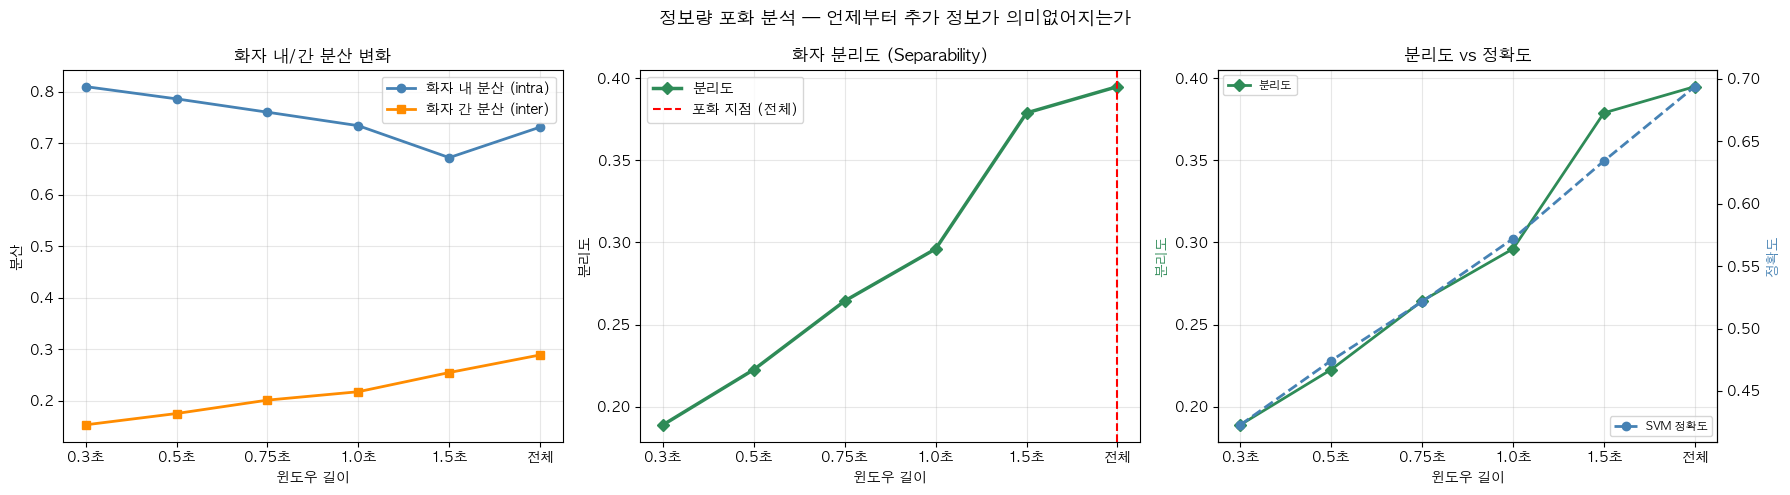

In [11]:
svm_accs = window_accs["SVM"]
deltas   = np.diff(separabilities)
sat_idx  = int(np.argmin(np.abs(deltas))) + 1 if len(deltas) > 0 else 0

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=DPI)

# 화자 내/간 분산
axes[0].plot(x, intra_vars, marker="o", linewidth=2,
             color="steelblue", label="화자 내 분산 (intra)")
axes[0].plot(x, inter_vars, marker="s", linewidth=2,
             color="darkorange", label="화자 간 분산 (inter)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(WINDOW_LABELS)
axes[0].set_title("화자 내/간 분산 변화")
axes[0].set_xlabel("윈도우 길이")
axes[0].set_ylabel("분산")
axes[0].legend()
axes[0].grid(alpha=0.3)

# 분리도 + 포화 지점
axes[1].plot(x, separabilities, marker="D", linewidth=2.5,
             color="seagreen", label="분리도")
axes[1].axvline(sat_idx, color="red", linestyle="--", linewidth=1.5,
                label=f"포화 지점 ({WINDOW_LABELS[sat_idx]})")
axes[1].set_xticks(x)
axes[1].set_xticklabels(WINDOW_LABELS)
axes[1].set_title("화자 분리도 (Separability)")
axes[1].set_xlabel("윈도우 길이")
axes[1].set_ylabel("분리도")
axes[1].legend()
axes[1].grid(alpha=0.3)

# 분리도 + 정확도 이중 y축
ax2 = axes[2].twinx()
axes[2].plot(x, separabilities, marker="D", linewidth=2,
             color="seagreen", label="분리도")
ax2.plot(x, svm_accs, marker="o", linewidth=2,
         color="steelblue", linestyle="--", label="SVM 정확도")
axes[2].set_xticks(x)
axes[2].set_xticklabels(WINDOW_LABELS)
axes[2].set_title("분리도 vs 정확도")
axes[2].set_xlabel("윈도우 길이")
axes[2].set_ylabel("분리도", color="seagreen")
ax2.set_ylabel("정확도", color="steelblue")
axes[2].legend(loc="upper left", fontsize=8)
ax2.legend(loc="lower right", fontsize=8)
axes[2].grid(alpha=0.3)

plt.suptitle("정보량 포화 분석 — 언제부터 추가 정보가 의미없어지는가", fontsize=13)
plt.tight_layout()
plt.show()

## 전체 요약 시각화

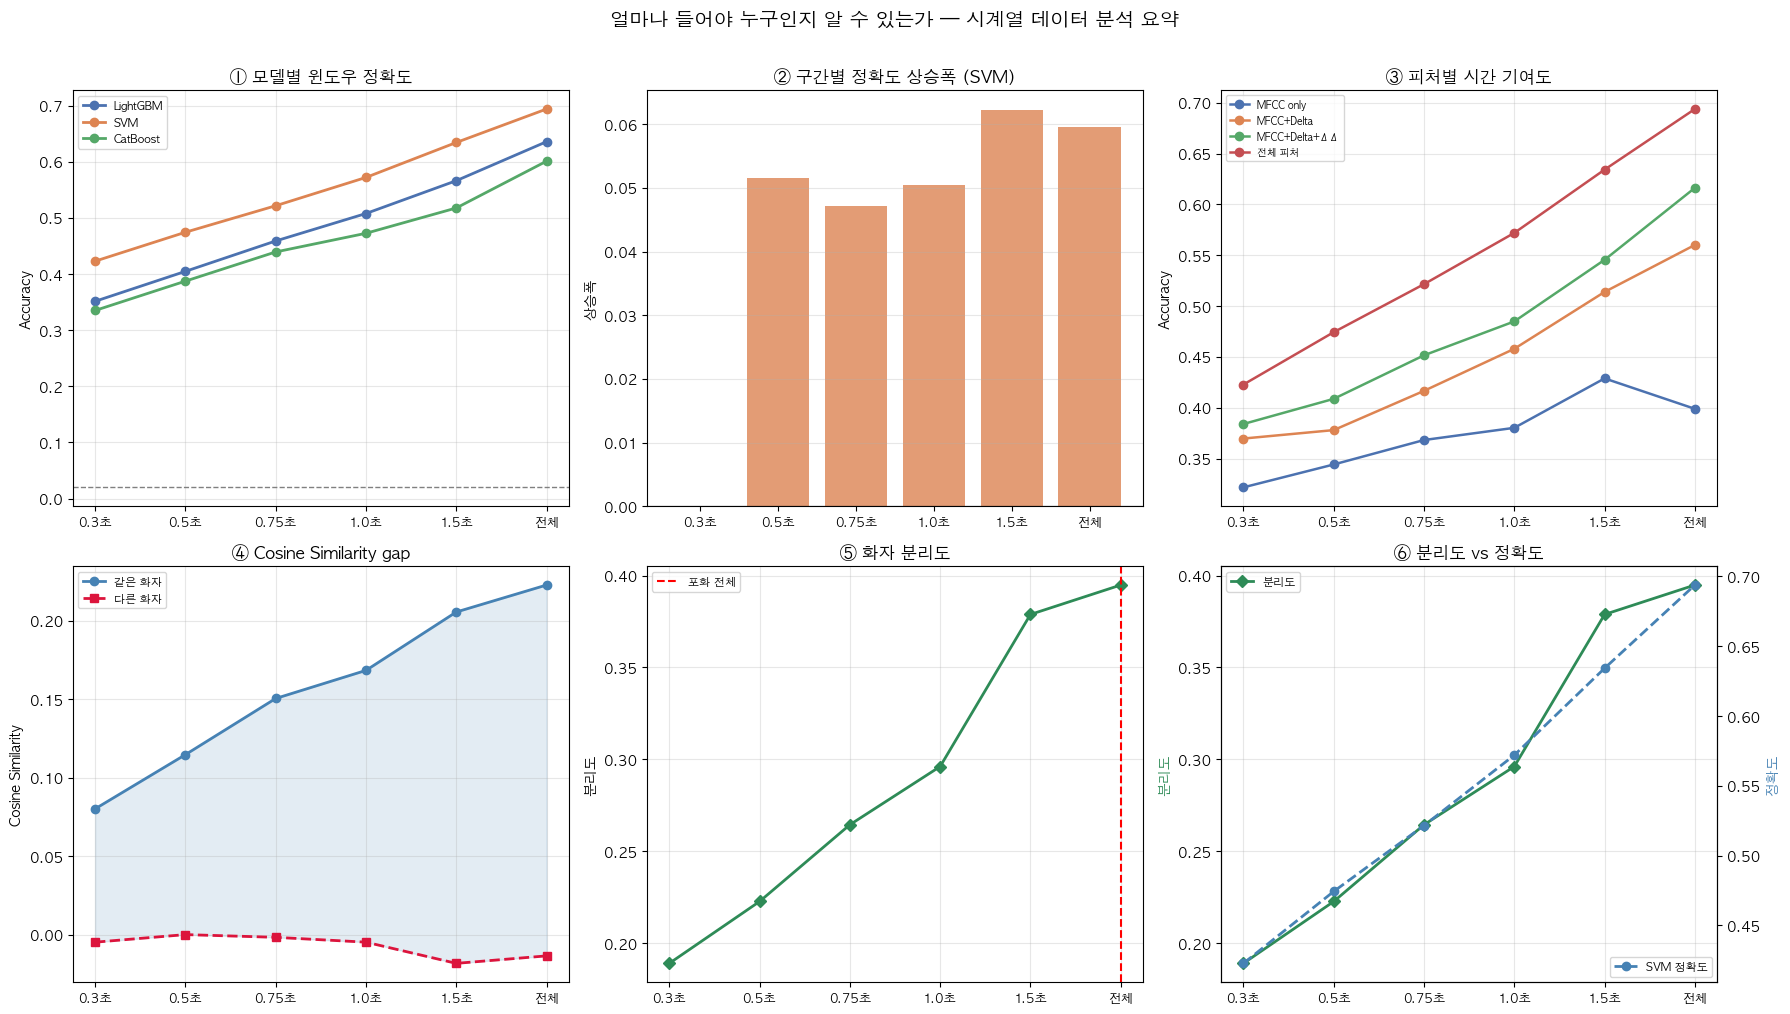

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=DPI)

# 1. 모델별 윈도우 정확도
for name, accs in window_accs.items():
    axes[0, 0].plot(x, accs, marker="o", linewidth=2,
                    color=colors[name], label=name)
axes[0, 0].axhline(1/NUM_SPEAKERS, color="gray", linestyle="--", linewidth=1)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(WINDOW_LABELS, fontsize=9)
axes[0, 0].set_title("① 모델별 윈도우 정확도")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(alpha=0.3)

# 2. 구간별 상승폭 (SVM)
gains_svm = [0] + [svm_accs[i] - svm_accs[i-1] for i in range(1, len(svm_accs))]
axes[0, 1].bar(x, gains_svm, color="#DD8452", alpha=0.8)
axes[0, 1].axhline(0, color="black", linewidth=0.8)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(WINDOW_LABELS, fontsize=9)
axes[0, 1].set_title("② 구간별 정확도 상승폭 (SVM)")
axes[0, 1].set_ylabel("상승폭")
axes[0, 1].grid(axis="y", alpha=0.3)

# 3. 피처별 기여도
for (fname, accs), color in zip(feat_results.items(), colors_feat):
    axes[0, 2].plot(x, accs, marker="o", linewidth=1.8,
                    color=color, label=fname)
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels(WINDOW_LABELS, fontsize=9)
axes[0, 2].set_title("③ 피처별 시간 기여도")
axes[0, 2].set_ylabel("Accuracy")
axes[0, 2].legend(fontsize=7)
axes[0, 2].grid(alpha=0.3)

# 4. Cosine Similarity
axes[1, 0].plot(x, same_sim_list, marker="o", linewidth=2,
                color="steelblue", label="같은 화자")
axes[1, 0].plot(x, diff_sim_list, marker="s", linewidth=2,
                color="crimson", linestyle="--", label="다른 화자")
axes[1, 0].fill_between(x, same_sim_list, diff_sim_list,
                         alpha=0.15, color="steelblue")
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(WINDOW_LABELS, fontsize=9)
axes[1, 0].set_title("④ Cosine Similarity gap")
axes[1, 0].set_ylabel("Cosine Similarity")
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(alpha=0.3)

# 5. 분리도
axes[1, 1].plot(x, separabilities, marker="D", linewidth=2, color="seagreen")
axes[1, 1].axvline(sat_idx, color="red", linestyle="--",
                    linewidth=1.5, label=f"포화 {WINDOW_LABELS[sat_idx]}")
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(WINDOW_LABELS, fontsize=9)
axes[1, 1].set_title("⑤ 화자 분리도")
axes[1, 1].set_ylabel("분리도")
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(alpha=0.3)

# 6. 분리도 + 정확도
ax6b = axes[1, 2].twinx()
axes[1, 2].plot(x, separabilities, marker="D", linewidth=2,
                color="seagreen", label="분리도")
ax6b.plot(x, svm_accs, marker="o", linewidth=2,
          color="steelblue", linestyle="--", label="SVM 정확도")
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(WINDOW_LABELS, fontsize=9)
axes[1, 2].set_title("⑥ 분리도 vs 정확도")
axes[1, 2].set_ylabel("분리도", color="seagreen")
ax6b.set_ylabel("정확도", color="steelblue")
axes[1, 2].legend(loc="upper left", fontsize=8)
ax6b.legend(loc="lower right", fontsize=8)
axes[1, 2].grid(alpha=0.3)

plt.suptitle(
    "얼마나 들어야 누구인지 알 수 있는가 — 시계열 데이터 분석 요약",
    fontsize=14, y=1.01
)
plt.tight_layout()
plt.show()

## 결론

**시계열 데이터로서의 음성 — 실험 결론**

1. **윈도우별 정확도**: 오디오 길이가 길어질수록 정확도가 단조 증가. 시간 정보가 누적될수록 화자 식별이 쉬워짐을 세 모델 모두에서 동일하게 확인.

2. **피처별 기여도**: Delta(시간 변화량) 추가 시 특히 짧은 윈도우에서 정확도 향상. MFCC만으로는 정적 음색만 잡지만 Delta는 시간 흐름을 반영.

3. **Cosine Similarity**: 윈도우가 길어질수록 같은 화자 유사도 상승, 다른 화자 유사도 하락. 모델 정확도가 아닌 피처 레벨에서도 동일한 패턴 확인 — 이 결과가 특정 모델이 아닌 데이터 자체의 시계열 특성에서 비롯됨.

4. **정보량 포화**: 분리도가 수렴하는 지점과 정확도가 수렴하는 지점이 일치. 피처 통계만으로도 같은 결론 도달.